In [1]:
import sys
import numpy as np

sys.path.append('/home/ismael/Documentos/GRANULARITY-PREDICTION/src/funcoes')
import pandas as pd
import polars as pl
pl.enable_string_cache()
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
import joblib
from funcoes_de_tratamento import *
import matplotlib.pyplot as plt
from time import perf_counter
from pathlib import Path

/tmp/ipykernel_1514155/3891571307.py:7: DeprecationWarning: the string cache has been replaced by pl.Categories
  pl.enable_string_cache()


In [2]:

FULL_DATASET_PATH = "../../data/tratados_stored"

FILLED_DATASET_PATH = "../../data/tratados"

pct_fill = ["0.05", "0.1", "0.15","0.2"]
fill_method = ["cubic", "granufill", "knn", "linear", "moving_average", "moving_median", "quadratic"]
gran = ["df_10min", "df_hour"]

In [15]:
rmses = pd.DataFrame(columns = ["granularity", "pct", "method", "RMSE"])
for g in gran:
    df = pd.read_parquet(FULL_DATASET_PATH + "/" + g + ".parquet").reset_index(drop = True)
    nan_indexes = df[df["n_bytes"] == np.nan].index
    df = df.drop(labels = nan_indexes, axis = 0)
    for p in pct_fill:
        PCT_FILL = FILLED_DATASET_PATH + "/" + p
        for m in fill_method:
            METHOD_FILL = PCT_FILL + "/" + m
            df_filled = pd.read_parquet(METHOD_FILL + "/" + g + ".parquet").reset_index(drop = True)
            df_filled = df_filled.drop(labels = nan_indexes, axis = 0)
            og = df["n_bytes"]
            filled = df_filled["n_bytes"]
            print(g,p,m)
            print(og)
            print(filled)
            rmse = np.sqrt(np.mean((og - filled)**2, axis=0)) + 0
            print(rmse)
            line = pd.DataFrame({
                "granularity": g,
                "pct": p,
                "method": m,
                "RMSE": rmse
            }, index= [len(rmses)])
            rmses = pd.concat([rmses,line])
            del line
rmses.to_csv("rmse_fills.csv", index = False)


df_10min 0.05 cubic
0          7.967274e+08
1          3.551760e+07
2          2.280902e+07
3          4.654356e+07
4          2.019183e+09
               ...     
4111411    3.511381e+06
4111412    1.774880e+06
4111413    6.689455e+08
4111414    5.391202e+07
4111415    6.806863e+08
Name: n_bytes, Length: 4111416, dtype: float64
0          7.967274e+08
1          3.551760e+07
2          2.280902e+07
3          4.654356e+07
4          2.019183e+09
               ...     
4111411    3.511381e+06
4111412    1.774880e+06
4111413    6.689455e+08
4111414    5.391202e+07
4111415    6.806863e+08
Name: n_bytes, Length: 4111416, dtype: float64
0.0
df_10min 0.05 granufill
0          7.967274e+08
1          3.551760e+07
2          2.280902e+07
3          4.654356e+07
4          2.019183e+09
               ...     
4111411    3.511381e+06
4111412    1.774880e+06
4111413    6.689455e+08
4111414    5.391202e+07
4111415    6.806863e+08
Name: n_bytes, Length: 4111416, dtype: float64
0          7.967274

/tmp/ipykernel_1514155/3861454851.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rmses = pd.concat([rmses,line])


df_10min 0.05 linear
0          7.967274e+08
1          3.551760e+07
2          2.280902e+07
3          4.654356e+07
4          2.019183e+09
               ...     
4111411    3.511381e+06
4111412    1.774880e+06
4111413    6.689455e+08
4111414    5.391202e+07
4111415    6.806863e+08
Name: n_bytes, Length: 4111416, dtype: float64
0          7.967274e+08
1          3.551760e+07
2          2.280902e+07
3          4.654356e+07
4          2.019183e+09
               ...     
4111411    3.511381e+06
4111412    1.774880e+06
4111413    6.689455e+08
4111414    5.391202e+07
4111415    6.806863e+08
Name: n_bytes, Length: 4111416, dtype: float64
0.0
df_10min 0.05 moving_average
0          7.967274e+08
1          3.551760e+07
2          2.280902e+07
3          4.654356e+07
4          2.019183e+09
               ...     
4111411    3.511381e+06
4111412    1.774880e+06
4111413    6.689455e+08
4111414    5.391202e+07
4111415    6.806863e+08
Name: n_bytes, Length: 4111416, dtype: float64
0          7.

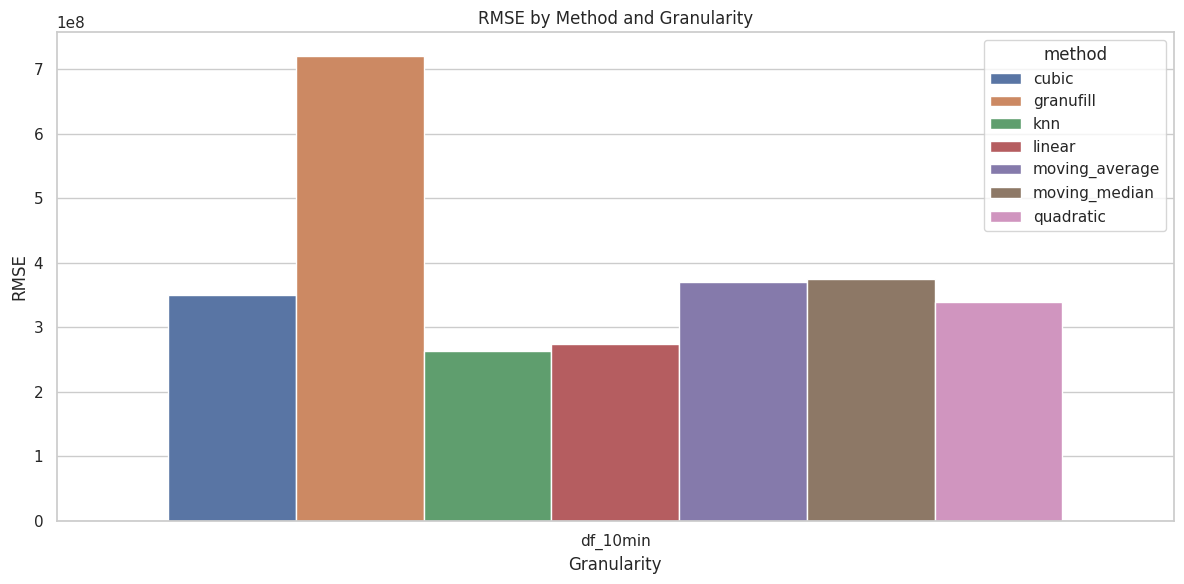

In [25]:
# ------------------------------------------------------------
# Plot RMSE values from `rmse_fills.csv`
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV (assumes it is in the same directory as the notebook)
df = pd.read_csv('rmse_fills.csv')
df = df[(df["granularity"] ==  "df_10min") & (df["pct"] ==  0.2)]
# Reshape data for a grouped bar chart
pivot = df.pivot_table(
    index=['granularity', 'pct'],
    columns='method',
    values='RMSE'
).reset_index()

melted = pivot.melt(
    id_vars=['granularity', 'pct'],
    var_name='method',
    value_name='RMSE'
)

# Plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=melted,
    x='granularity',
    y='RMSE',
    hue='method'
)

plt.title('RMSE by Method and Granularity')
plt.xlabel('Granularity')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()


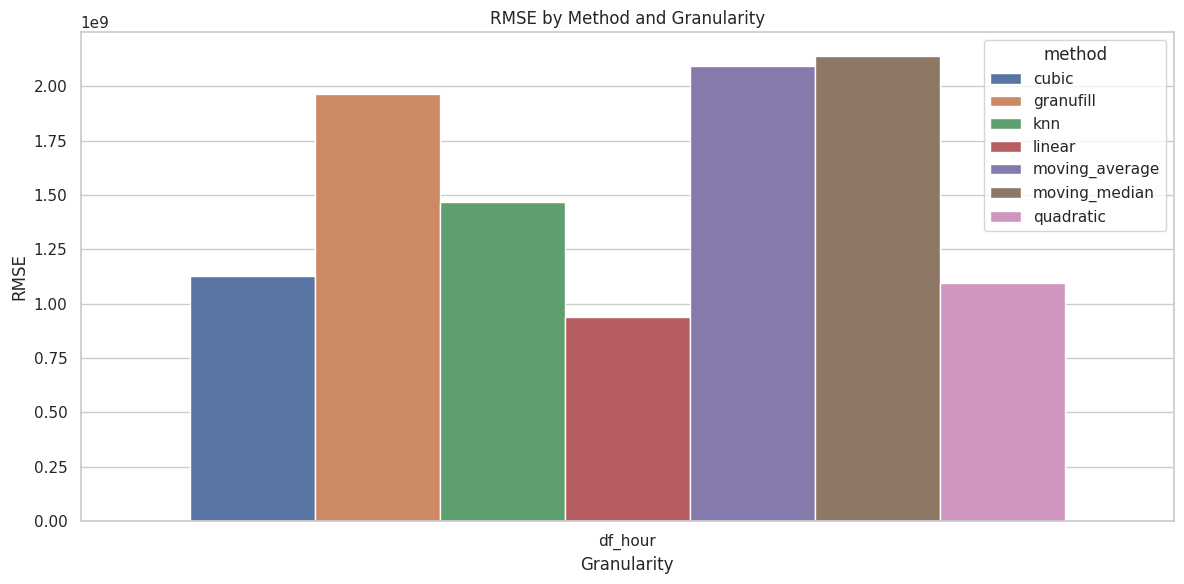

In [24]:
# ------------------------------------------------------------
# Plot RMSE values from `rmse_fills.csv`
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV (assumes it is in the same directory as the notebook)
df = pd.read_csv('rmse_fills.csv')
df = df[(df["granularity"] ==  "df_hour")& (df["pct"] ==  0.2)]
# Reshape data for a grouped bar chart
pivot = df.pivot_table(
    index=['granularity', 'pct'],
    columns='method',
    values='RMSE'
).reset_index()

melted = pivot.melt(
    id_vars=['granularity', 'pct'],
    var_name='method',
    value_name='RMSE'
)

# Plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=melted,
    x='granularity',
    y='RMSE',
    hue='method'
)

plt.title('RMSE by Method and Granularity')
plt.xlabel('Granularity')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()